## Packages

- numpy: https://numpy.org/
- pandas: https://pandas.pydata.org/
- matplotlib: https://matplotlib.org/
- sklearn: https://scikit-learn.org/stable/index.html
- umap: https://umap-learn.readthedocs.io/en/latest/
- hdbscan: https://pypi.org/project/hdbscan/
- optuna: https://optuna.org/

In [1]:
# Numerical
import numpy as np

# Tabular
import pandas as pd

# Machine learning
from sklearn.preprocessing import StandardScaler
import hdbscan
import optuna
import umap

# Visual
import matplotlib.pyplot as plt

C:\Users\Legion\AppData\Roaming\Python\Python310\site-packages\matplotlib\projections\__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Sample

In [14]:
def generate_interlocking_donuts(num_points=10000):
    np.random.seed(42)
    
    # Half points per donut
    n = num_points // 2
    
    # First donut (lying in x-y plane)
    theta1 = np.random.uniform(0, 2*np.pi, n)
    phi1 = np.random.uniform(0, 2*np.pi, n)
    R1, r1 = 5.0, 2.0  # Major and minor radii
    
    donut1 = np.column_stack([
        (R1 + r1 * np.cos(theta1)) * np.cos(phi1),  # x
        (R1 + r1 * np.cos(theta1)) * np.sin(phi1),  # y
        r1 * np.sin(theta1)                         # z
    ])
    
    # Second donut (lying in x-z plane, rotated 90 degrees and shifted)
    theta2 = np.random.uniform(0, 2*np.pi, n)
    phi2 = np.random.uniform(0, 2*np.pi, n)
    R2, r2 = 5.0, 0.5  # Major and minor radii
    
    donut2 = np.column_stack([
        R1 + (R2 + r2 * np.cos(theta2)) * np.cos(phi2),  # x
        r2 * np.sin(theta2),                        # y
        (R2 + r2 * np.cos(theta2)) * np.sin(phi2)   # z
    ])
    
    # Combine and add noise
    data = np.vstack([donut1, donut2])
    data += np.random.normal(0, 0.5, data.shape)
    
    # Labels (0 for first donut, 1 for second)
    labels = np.concatenate([np.zeros(n), np.ones(n)])
    
    # Convert to DataFrame
    sample = pd.DataFrame(data)
    
    return sample, labels

# Generate the data
sample, _ = generate_interlocking_donuts(10000)

In [15]:
sample.head()

,0,1,2
0,-3.219495,2.517495,2.071434
1,-7.422369,2.003293,-0.673766
2,2.427898,-3.401796,-2.210441
3,-1.847816,2.644982,-1.570259
4,4.537197,-4.608943,0.942996


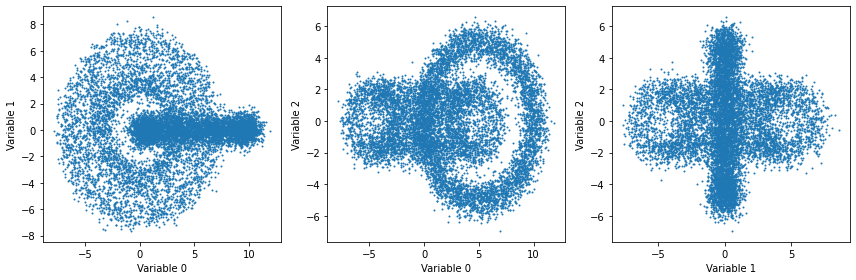

In [16]:
plt.figure(figsize=(12, 4), layout='tight')

plt.subplot(1, 3, 1)
plt.scatter(sample[0], sample[1], s=1)
plt.xlabel('Variable 0')
plt.ylabel('Variable 1')

plt.subplot(1, 3, 2)
plt.scatter(sample[0], sample[2], s=1)
plt.xlabel('Variable 0')
plt.ylabel('Variable 2')

plt.subplot(1, 3, 3)
plt.scatter(sample[1], sample[2], s=1)
plt.xlabel('Variable 1')
plt.ylabel('Variable 2')
plt.show()

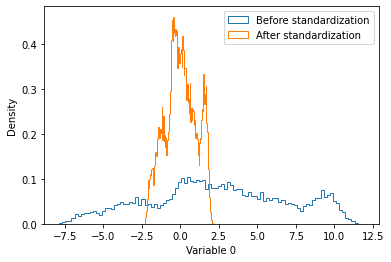

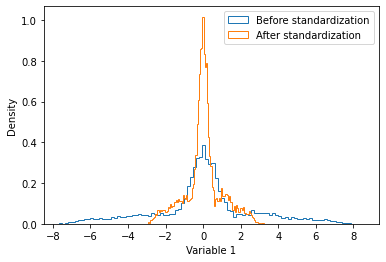

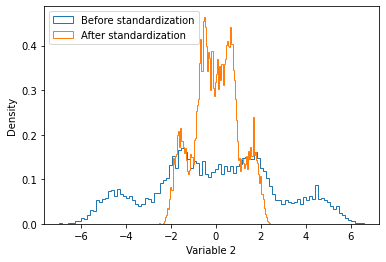

In [17]:
# Standardize the data
X = StandardScaler().fit_transform(sample)

hist_kwargs = {
    'histtype' : 'step',
    'bins'     : 100,
    'density'  : True
}


for i in range(sample.shape[1]):
    plt.hist(
        sample.values[:, i],
        label = 'Before standardization',
        **hist_kwargs
    )

    plt.hist(
        X[:, i],
        label = 'After standardization',
        **hist_kwargs
    )

    plt.xlabel(f'Variable {i}')
    plt.ylabel('Density')
    plt.legend(loc='best')

    plt.show()

## UMAP

See the UMAP paper: https://doi.org/10.48550/arXiv.1802.03426

UMAP(n_epochs=1000, verbose=True)
Mon Apr 14 23:28:54 2025 Construct fuzzy simplicial set
Mon Apr 14 23:28:54 2025 Finding Nearest Neighbors
Mon Apr 14 23:28:54 2025 Building RP forest with 10 trees
Mon Apr 14 23:28:55 2025 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	Stopping threshold met -- exiting after 2 iterations
Mon Apr 14 23:28:55 2025 Finished Nearest Neighbor Search
Mon Apr 14 23:28:55 2025 Construct embedding


Epochs completed:   0%|            0/1000 [00:00]

	completed  0  /  1000 epochs
	completed  100  /  1000 epochs
	completed  200  /  1000 epochs
	completed  300  /  1000 epochs
	completed  400  /  1000 epochs
	completed  500  /  1000 epochs
	completed  600  /  1000 epochs
	completed  700  /  1000 epochs
	completed  800  /  1000 epochs
	completed  900  /  1000 epochs
Mon Apr 14 23:29:03 2025 Finished embedding


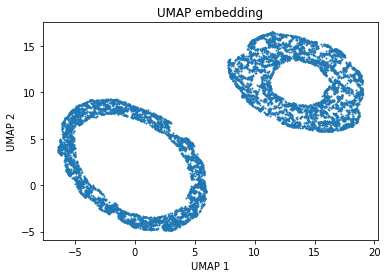

In [18]:
# Define UMAP hyperparameters
hyperparameters = {
    'n_neighbors' : 15,
    'min_dist'    : 0.10,
    'n_epochs'    : 1000,
    'verbose'     : True
}

# Run UMAP
model = umap.UMAP(
    **hyperparameters
)

embedding = model.fit_transform(X)


# Plot
plt.title('UMAP embedding')
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    s=1
)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')

plt.show()

## Trustworthiness, optimized to consume less RAM

Sklearn has a trustworthiness function but it is not RAM effecient. For that reason, I rewrote the function.

See the Trustworthiness paper: https://doi.org/10.1007/3-540-44668-0_68

In [19]:
def trustworthiness_low_memory(
    X, 
    X_embedding, 
    k=15
):
    
    """Calculates the trustworthiness score.

    Parameters
    ----------
    X : Numpy array
        Original space used to construct the embedding.
    X_embedding : Numpy array
        The embedding space.
    k : int
        Number of nearest neighbors for the trustworthiness score.
        
    Returns
    -------
    t_score : float
        The trustworthiness score.
    
    """
    
    from sklearn.neighbors import NearestNeighbors
    import numpy as np
    import time
    
    n_samples = X.shape[0]
    
    ## Initialize the Trustworthiness score (t_score)
    t_score = 1
    t_punishment = 0
    punishment_constant = (2.0 / (n_samples * k * (2.0 * n_samples - 3.0 * k - 1.0)))
    
    ## Compute k-Nearest Neighbours in the embedding space
    ## Obtain the indices
    t0 = time.time()
    print('Finding Nearest Neighbours...')
    ind_X_embedded = (
        NearestNeighbors(n_neighbors=k)
        .fit(X_embedding)
        .kneighbors(return_distance=False)
    )
    t1 = time.time()
    print(f'Nearest Neighbours found. Time elapsed: {t1 - t0:.3f} s')
    
    ## For every point i (i_embedding)
    ## There is a neighbourhood kNi in the embedding space (kNi_embedding)
    t0 = time.time()
    for i in range(n_samples):
        #print(f'{i}/{n_samples} n_samples. Trustworthiness score: {t_score}')
        ## Distances from the point i to all the other points in the input (including itself)
        dist_X = np.sqrt(np.sum((X - X[i])**2, axis=1))
        dist_X[i] = np.inf # Exclude the point itself as a neighbor

        ## Indices of sorted distances between i and other samples
        ind_X = np.argsort(dist_X)

        ## Ranks r(i, j) in the input
        ranks = np.where(np.isin(ind_X, ind_X_embedded[i]))[0]
        
        ## Trustworthiness score (punishment part)
        #t_punishment += np.sum(ranks[ranks > 0])
        t_punishment += np.sum(np.maximum(0, ranks - k))
    t_score -= t_punishment * punishment_constant
    t1 = time.time()
    print(f'T(k = {k}) = {t_score:.6f} after {i+1} iterations in {t1 - t0:.3f} seconds.')
    return t_score

In [20]:
# Make sure that the original space is the one you plugged into the UMAP
t_score = trustworthiness_low_memory(
    X           = X , 
    X_embedding = embedding, 
    k           = 15
)

Finding Nearest Neighbours...
Nearest Neighbours found. Time elapsed: 0.031 s
T(k = 15) = 0.994120 after 10000 iterations in 9.239 seconds.


## HDBSCAN

See the HBDSCAN papers: 
- https://doi.org/10.1007/978-3-642-37456-2_14
- https://doi.org/10.1109/ICDMW.2017.12

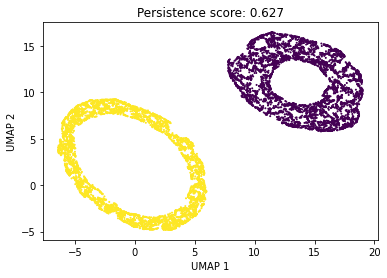

In [21]:
# Define the hyperparameters
hyperparams = {
    'min_cluster_size'          : 100,
    'min_samples'               : 100,
    'cluster_selection_method'  : 'eom',
    'cluster_selection_epsilon' : 0.00,
    'allow_single_cluster'      : False
}

# Run HDBSCAN on the embedding
clusterer = hdbscan.HDBSCAN(
        **hyperparams
    )

clusterer_results = clusterer.fit(embedding)

# Extract labels and persistence score
labels = clusterer_results.labels_
persistence = clusterer_results.cluster_persistence_
persistence_mean = np.mean(clusterer.cluster_persistence_)

# Plot
plt.title(f'Persistence score: {persistence_mean:.3f}')
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    s=1,
    c=labels
)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')

plt.show()

## Optuna

It is a hyperparameter optimization package. This will be used to optimize the HDBSCAN hyperparameters.

See the paper: https://doi.org/10.1145/3292500.3330701

In [22]:
# Define the objective function for Optuna
def objective(trial, X):
    
    # Define hyperparams
    min_cluster_size = trial.suggest_int(
        name = 'min_cluster_size', 
        low  = 100, 
        high = 1000
    )
    min_samples = trial.suggest_int(
        name = 'min_samples', 
        low  = int(min_cluster_size / 4), 
        high = min_cluster_size
    )
    cluster_selection_method = trial.suggest_categorical(
        name    = 'cluster_selection_method',
        choices = ['eom', 'leaf']
    )
    cluster_selection_epsilon = trial.suggest_float(
        'cluster_selection_epsilon', 
        low  = 0.0,
        high = 0.0
    )
    allow_single_cluster = trial.suggest_categorical(
        name    = 'allow_single_cluster',
        choices = [False]
    )
    
    hyperparams = {
        'min_cluster_size'          : min_cluster_size,
        'min_samples'               : min_samples,
        'cluster_selection_method'  : cluster_selection_method,
        'cluster_selection_epsilon' : cluster_selection_epsilon,
        'allow_single_cluster'      : allow_single_cluster
    }
    
    # Initialize HDBSCAN with suggested hyperparameters
    clusterer = hdbscan.HDBSCAN(
        **hyperparams
    )
    
    # Fit HDBSCAN to the data
    clusterer.fit(X)

    # Handle cases where the algorithm returns no clusters (e.g., all noise)
    if len(np.unique(clusterer.labels_)) <= 1:
        return -np.inf  # Return a very poor score
    else:
        # Calculate the cluster persistence score (built-in for HDBSCAN)
        persistence = np.mean(clusterer.cluster_persistence_)
        # Handle cases where the score is somehow anomalous (bad clustering)
        if abs(persistence) > 1:
            return -np.inf
        # Return the persistence score
        else:
            return persistence

In [23]:
# Do not show the logs
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Number of optuna trials
n_trials = 100

# Set up the Optuna study
study_name = f'Sample_HDBSCAN'
study = optuna.create_study(direction="maximize", study_name=study_name)

# Run study (on the embedding)
study.optimize(lambda trial: objective(trial, embedding), n_trials=n_trials)

# Get best params and score
best_params = study.best_params
score = study.best_value

print(f'With a final score of {score:.3f}, the best parameters are:\n {best_params}')

With a final score of 0.726, the best parameters are:
 {'min_cluster_size': 997, 'min_samples': 301, 'cluster_selection_method': 'eom', 'cluster_selection_epsilon': 0.0, 'allow_single_cluster': False}


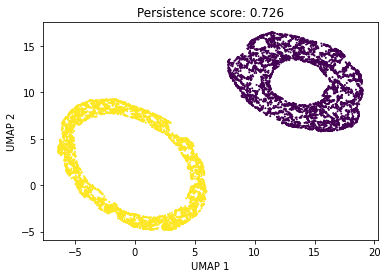

In [24]:
# Run HDBSCAN on the embedding
clusterer = hdbscan.HDBSCAN(
        **best_params
    )

clusterer_results = clusterer.fit(embedding)

# Extract labels and persistence score
labels = clusterer_results.labels_
persistence = clusterer_results.cluster_persistence_
persistence_mean = np.mean(clusterer.cluster_persistence_)


# Plot
plt.title(f'Persistence score: {persistence_mean:.3f}')
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    s=1,
    c=labels
)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')

plt.show()

## Plot results

Verify if the results make sense.

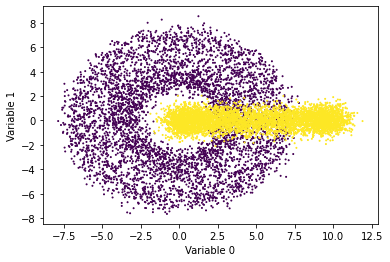

In [25]:
plt.scatter(
    sample[0],
    sample[1],
    s=1,
    c=labels
)
plt.xlabel('Variable 0')
plt.ylabel('Variable 1')
plt.show()